In [ ]:
#@title Graph RAG Solution for Personalized Medicine using MedRAG and Diabetes Data

SyntaxError: invalid syntax (2663151521.py, line 1)

In [2]:
# Install necessary libraries (if not already installed)
!pip install networkx matplotlib scikit-learn PyPDF2 google-genai gremlinpython nltk boto3==1.37

In [2]:
# !pip install torch-scatter torch-sparse torch-cluster torch-spline-conv torch-geometric

In [3]:
# Import libraries
import os
import glob
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import PyPDF2
import nltk
import json, requests
nltk.download("punkt")
nltk.download('punkt_tab')
from nltk.tokenize import sent_tokenize
from google import genai
from gremlin_python.driver import client, serializer
import boto3

[nltk_data] Downloading package punkt to /Users/jmmokdad/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/jmmokdad/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [4]:
# Set random seed for reproducibility
import numpy as np

RANDOM_SEED = 42

np.random.seed(RANDOM_SEED)

In [ ]:
# Set data directory for MIMIC-IV and additional diabetes-related resources
# DATA_DIR = "mimic4_data"

DATA_DIR = "datasets/diabetes_care"

GEMINI_MODEL_NAME = "gemini-2.0-flash"
BEDROCK_MODEL_NAME = "us.anthropic.claude-3-7-sonnet-20250219-v1:0"

SIMILARITY_THRESHOLD = 0.2

In [ ]:
# from google.colab import userdata

# # https://ai.google.dev/gemini-api/docs/quickstart?lang=python
# GEMINI_API_KEY = userdata.get("GOOGLE_API_KEY")

GEMINI_API_KEY = "ENTER YOUR KEY"

In [ ]:
gemini_client = genai.Client(api_key=GEMINI_API_KEY)

# Instantiate the AWS Bedrock client for Claude 3.7.
bedrock_client = boto3.client(
    "bedrock-runtime",
    region_name="us-east-1",  # Update to your region
    aws_access_key_id="YOUR ACCESS KEY",  # Replace with your AWS access key
    aws_secret_access_key="YOUR SECRET KEY",  # Replace with your AWS secret key
    aws_session_token="YOUR SESSION TOKEN"
)

In [7]:
# from google.colab import drive
# drive.mount('/content/drive')

In [8]:
# --- Step 1: Load and augment data
# Load text files from the folder
file_paths = glob.glob(os.path.join(DATA_DIR, "*.pdf"))
documents = []
doc_names = []
for file_path in file_paths:
    # Open the PDF file in binary mode
    with open(file_path, "rb") as file:
        reader = PyPDF2.PdfReader(file)
        text = ""
        for page in reader.pages:
            page_text = page.extract_text()
            if page_text:
                text += page_text

    # print(text)
    documents.append(text)
    doc_names.append(os.path.basename(file_path))

path_txt = glob.glob(os.path.join(DATA_DIR, "*.txt"))
for file_path in path_txt:
    # Open the PDF file in binary mode
    with open(file_path, "r") as file:
        text = file.read()

    # print(text)
    documents.append(text)
    doc_names.append(os.path.basename(file_path))

print("Loaded documents:")
for name, doc in zip(doc_names, documents):
    print(f"- {name}: {doc[:60]}...")


Loaded documents:
- dc25s005.pdf: 5. Facilitating Positive Health
Behaviors and Well-being toI...
- dc25s011.pdf: 11. Chronic Kidney Disease and
Risk Management: Standards of...
- dc25s010.pdf: 10. Cardiovascular Disease and
Risk Management: Standards of...
- dc25s004.pdf: 4. Comprehensive Medical
Evaluation and Assessment ofComorbi...
- dc25s012.pdf: 12. Retinopathy, Neuropathy, and
Foot Care: Standards of Car...
- dc25s006.pdf: 6. Glycemic Goals and
Hypoglycemia: Standards of Carein Diab...
- dc25s007.pdf: 7. Diabetes Technology: Standards
of Care in Diabetes —2025
...
- dc25s013.pdf: 13. Older Adults: Standards of
Care in Diabetes —2025
Diabet...
- dc25s017.pdf: 17. Diabetes Advocacy: Standards
of Care in Diabetes —2025
D...
- dc25s003.pdf: 3. Prevention or Delay of
Diabetes and AssociatedComorbiditi...
- dc25s002.pdf: 2. Diagnosis and Classification of
Diabetes: Standards of Ca...
- dc25s016.pdf: 16. Diabetes Care in the Hospital:
Standards of Care in Diab...
- dc25s014.pdf: 14. Ch

In [14]:
# Simple data augmentation: create variations by (for example) adding a prefix or lowercasing.
def augment_text(text):
    # For demonstration, generate 2 variations
    augmented = []
    augmented.append(text.lower())
    # augmented.append("Augmented: " + text)
    return augmented

augmented_docs = []
augmented_sources = []
for doc, name in zip(documents, doc_names):
    variations = augment_text(doc)
    augmented_docs.extend(variations)
    augmented_sources.extend([name] * len(variations))

print(f"Total augmented documents: {len(augmented_docs)}")

Total augmented documents: 17


In [15]:
# --- Step 2: Chunk the documents
# TODO: generate chunks with overlap
# We split each document into chunks by grouping sentences (here, 2 sentences per chunk)
def chunk_text(text, chunk_size=2):
    sentences = sent_tokenize(text)
    chunks = [' '.join(sentences[i:i+chunk_size]) for i in range(0, len(sentences), chunk_size)]
    return chunks

all_chunks = []
chunk_source = []  # To record the source of each chunk
for doc, name in zip(augmented_docs, augmented_sources):
    chunks = chunk_text(doc)
    all_chunks.extend(chunks)
    chunk_source.extend([name] * len(chunks))

print(f"Total chunks created: {len(all_chunks)}")
print("Sample chunk:", all_chunks[0])

Total chunks created: 6823
Sample chunk: 5. facilitating positive health
behaviors and well-being toimprove health outcomes:
standards of care in
diabetes —2025
diabetes care 2025;48(suppl. 1):s86 –s127 |https://doi.org/10.2337/dc25-s005american diabetes association
professional practice committee *
the american diabetes association (ada) “standards of care in diabetes ”includes
the ada ’s current clinical practice recommendations and is intended to provide the
components of diabetes care, general treatment goals and guidelines, and tools toevaluate quality of care.


In [ ]:
# --- Step 3: Data Augmentation: Intent and Entity Recognition using Gemini ---
# Functions to call Gemini/Bedrock API for intent detection and entity recognition.
# For demonstration, we simulate the API calls.
def gemini_intent_detection(prompt):
    response = gemini_client.models.generate_content(
        model=GEMINI_MODEL_NAME,
        contents=prompt,
        config={'response_mime_type': 'application/json'}
    )
    print(response.text)
    return response.text

def gemini_entity_recognition(prompt):
    response = gemini_client.models.generate_content(
        model=GEMINI_MODEL_NAME,
        contents=prompt,
        config={'response_mime_type': 'application/json'}
    )
    # print(response.text)
    return response.text

def bedrock_intent_detection(prompt, chunk):
    # Construct payload using the Messages API format.
    payload = {
        "system": prompt,
        "anthropic_version": "bedrock-2023-05-31", 
        "messages": [
            {"role": "user", "content": chunk}
        ],
        "max_tokens": 2000
    }
    response = bedrock_client.invoke_model(
        modelId=BEDROCK_MODEL_NAME,
        body=json.dumps(payload)
    )
    intent_output = json.loads(response['body'].read().decode('utf-8'))
    print("Intent output", intent_output)
    intent_output = json.loads(intent_output['content'][0]['text']) if intent_output['content'][0]['text'] else []
    print("Intent detection response:", intent_output)
    return intent_output

def bedrock_entity_recognition(prompt, chunk):
    # Construct payload using the Messages API format.
    payload = {
        "system": prompt,
        "anthropic_version": "bedrock-2023-05-31", 
        "messages": [
            {"role": "user", "content": chunk}
        ],
        "max_tokens": 2000
    }
    response = bedrock_client.invoke_model(
        modelId=BEDROCK_MODEL_NAME,
        body=json.dumps(payload)
    )
    entity_output = json.loads(response['body'].read().decode('utf-8'))
    entity_output = json.loads(entity_output['content'][0]['text'])
    print("Output recognition response:", entity_output)
    return entity_output

# For each chunk (or for a sample of chunks), generate JSON containing intent and entities.
def process_chunk(chunk):
    # Create a prompt for intent detection
    # intent_prompt = f"""
    # You are a medical expert. Your task is to analyze a text Analyze to determine the user query intent related to diabetes management\n\n.

    # Analyze the user’s question one by one to check if it fits into the nine predefined query categories. Ensure all potential intents are fully considered.
    # The intent categories to identify are: querying disease overview, causes, required medications, recommended foods, foods to avoid, necessary tests, symptoms, treatment methods, and concurrent diseases. \n\n

    # For each of the nine predefined categories, determine if it matches the user’s question. If a match is found, add the category to the output list.\n\n

    # Consider not only explicit intent but also identify the implicit intent within the user’s question, ensuring no important categories are overlooked.\n\n

    # Add all matched categories to the output list to ensure comprehensive coverage of the user’s intents, avoiding any omissions.

    # Your output should be a JSON array with the following structure:
    # ["intent1", "intent2", ...]\n\n

    # Below is the user’s question:

    # {chunk}
    # """
    intent_prompt = f"""
    You are a medical expert. Your task is to analyze a text Analyze to determine the user query intent related to diabetes management\n\n.

    Analyze the user’s question one by one to check if it fits into the nine predefined query categories. Ensure all potential intents are fully considered.
    The intent categories to identify are: querying disease overview, causes, required medications, recommended foods, foods to avoid, necessary tests, symptoms, treatment methods, and concurrent diseases. \n\n

    For each of the nine predefined categories, determine if it matches the user’s question. If a match is found, add the category to the output list.\n\n

    Consider not only explicit intent but also identify the implicit intent within the user’s question, ensuring no important categories are overlooked.\n\n

    Add all matched categories to the output list to ensure comprehensive coverage of the user’s intents, avoiding any omissions.

    Your output should be a JSON array with the following structure:
    ["intent1", "intent2", ...]\n\n
    """
    # intent_result = json.loads(gemini_intent_detection(intent_prompt))
    intent_result = bedrock_intent_detection(intent_prompt, chunk)

    # Create a prompt for entity recognition
    # Prompt 1: Extraction for Surgery, Location, Clinical Manifestations, Examination Indicators, Medication Dosage, and Examination Methods
    # entity_prompt_1 = f"""
    # You are a medical entity extraction assistant. Given the following text describing a medical condition, extract the following information in JSON format:

    # - "Surgery": a list of surgical interventions performed (if any).
    # - "Location": a list of body parts or anatomical locations affected.
    # - "Clinical Manifestations": a list of observable symptoms or physical signs.
    # - "Examination Indicators": a list of diagnostic test indicators or findings.
    # - "Medication Dosage": a list of details regarding dosages of any medications mentioned.
    # - "Examination Methods": a list of examination or diagnostic techniques referenced.

    # Return empty lists for any category where no information is present.
    # Return only the JSON object without any markdown code blocks, formatting, or additional commentary. Do not wrap the output in triple backticks.

    # Text: {chunk}
    # """
    entity_prompt_1 = f"""
    You are a medical entity extraction assistant. Given the following text describing a medical condition, extract the following information in JSON format:

    - "Surgery": a list of surgical interventions performed (if any).
    - "Location": a list of body parts or anatomical locations affected.
    - "Clinical Manifestations": a list of observable symptoms or physical signs.
    - "Examination Indicators": a list of diagnostic test indicators or findings.
    - "Medication Dosage": a list of details regarding dosages of any medications mentioned.
    - "Examination Methods": a list of examination or diagnostic techniques referenced.

    Return empty lists for any category where no information is present.
    Return only the JSON object without any markdown code blocks, formatting, or additional commentary. Do not wrap the output in triple backticks.
    """

    # Prompt 2: Prompt 2: Extraction for Medication Name, Disease Staging and Classification, Adverse Reactions, Medication Frequency, Cause, and Severity
    # entity_prompt_2 = f"""
    # You are a medical entity extraction assistant. Please analyze the following text describing a medical condition and extract the relevant medical entities in JSON format under these categories:

    # - "Medication Name": a list of medications mentioned.
    # - "Disease Staging and Classification": a list detailing disease stage or classification.
    # - "Adverse Reactions": a list of any adverse reactions noted.
    # - "Medication Frequency": a list specifying how often medications are to be taken.
    # - "Cause": a list of potential causes or etiologies described.
    # - "Severity": a list indicating the severity of the condition.

    # Return empty lists for any category without corresponding information.
    # Return only the JSON object without any markdown code blocks, formatting, or additional commentary. Do not wrap the output in triple backticks.

    # Text: {chunk}
    # """
    entity_prompt_2 = f"""
    You are a medical entity extraction assistant. Please analyze the following text describing a medical condition and extract the relevant medical entities in JSON format under these categories:

    - "Medication Name": a list of medications mentioned.
    - "Disease Staging and Classification": a list detailing disease stage or classification.
    - "Adverse Reactions": a list of any adverse reactions noted.
    - "Medication Frequency": a list specifying how often medications are to be taken.
    - "Cause": a list of potential causes or etiologies described.
    - "Severity": a list indicating the severity of the condition.

    Return empty lists for any category without corresponding information.
    Return only the JSON object without any markdown code blocks, formatting, or additional commentary. Do not wrap the output in triple backticks.
    """

    # Prompt 3: Extraction for Non-Medication Treatment, Pathogenesis, Examination Indicator Values, Medication Methods, Duration, and Diseases
    # entity_prompt_3 = f"""
    # You are a medical entity extraction assistant. Given the following description of a medical condition, output the extracted information in JSON format with the keys below:

    # - "Non-Medication Treatment": a list of treatment approaches that are not medications.
    # - "Pathogenesis": a list describing the disease mechanism or development process.
    # - "Examination Indicator Values": a list of specific values or metrics from diagnostic tests.
    # - "Medication Methods": a list of methods by which medications are administered (if any).
    # - "Duration": a list indicating the time period related to the condition.
    # - "Diseases": a list of diseases or conditions mentioned in the text.

    # Return empty lists for any category where the information is not present.
    # Return only the JSON object without any markdown code blocks, formatting, or additional commentary. Do not wrap the output in triple backticks.

    # Text: {chunk}
    # """
    entity_prompt_3 = f"""
    You are a medical entity extraction assistant. Given the following description of a medical condition, output the extracted information in JSON format with the keys below:

    - "Non-Medication Treatment": a list of treatment approaches that are not medications.
    - "Pathogenesis": a list describing the disease mechanism or development process.
    - "Examination Indicator Values": a list of specific values or metrics from diagnostic tests.
    - "Medication Methods": a list of methods by which medications are administered (if any).
    - "Duration": a list indicating the time period related to the condition.
    - "Diseases": a list of diseases or conditions mentioned in the text.

    Return empty lists for any category where the information is not present.
    Return only the JSON object without any markdown code blocks, formatting, or additional commentary. Do not wrap the output in triple backticks.
    """

    # TODO
    # Generate a name for the chunk so it represents the node in the graph

    # entity_result_1 = json.loads(gemini_entity_recognition(entity_prompt_1))
    # entity_result_2 = json.loads(gemini_entity_recognition(entity_prompt_2))
    # entity_result_3 = json.loads(gemini_entity_recognition(entity_prompt_3))
    entity_result_1 = bedrock_entity_recognition(entity_prompt_1, chunk)
    entity_result_2 = bedrock_entity_recognition(entity_prompt_2, chunk)
    entity_result_3 = bedrock_entity_recognition(entity_prompt_3, chunk)

    entity_result = {
        **entity_result_1,
        **entity_result_2,
        **entity_result_3
    }

    # Combine into a single JSON output
    result = {
        "text": chunk,
        "source": chunk_source[all_chunks.index(chunk)],
        "intent": intent_result,
        "entities": entity_result
    }
    return result

In [83]:
# # TODO: run process_chunk for all chunks. This is done for demo purposes to reduce Gemini quota.
# processed_data = [process_chunk(chunk) for chunk in all_chunks[:2]]

# # Save processed data as JSON for training/testing
# with open("datasets/chunks/processed_data.json", "w") as f:
#     json.dump(processed_data, f, indent=2)

# print("Processed data (sample):")
# print(json.dumps(processed_data, indent=2))

# Define parameters: start index and number of chunks to process (set as needed)
start_index = 881  # Modify this value to skip initial chunks
num_chunks_to_process = 2000  # Change this to process a specific number of chunks

# Process each chunk one-by-one and save the result in separate JSON files
for i in range(start_index, min(start_index + num_chunks_to_process, len(all_chunks))):
    # Process the chunk using the process_chunk() function defined earlier.
    try:
        result = process_chunk(all_chunks[i])
    except Exception as e:
        try:
            result = process_chunk(all_chunks[i])
        except:
            result = process_chunk(all_chunks[i])
    
    # Use part of the source file name from the chunk_source list to generate the output file name.
    # For example, if chunk_source[i] is "dc25sint.pdf", we'll use "dc25sint" in the file name.
    source_part = chunk_source[i].split('.')[0]
    output_filename = f"datasets/chunks/diabetes_care/processed_{source_part}_chunk_{i}.json"
    
    # Save the processed result for this chunk into a separate JSON file.
    with open(output_filename, "w") as f:
        json.dump(result, f, indent=2)
    
    print(f"Saved processed chunk {i} to file '{output_filename}'")

Intent output {'id': 'msg_bdrk_0179SYBaezFDhUj93PE5dc81', 'type': 'message', 'role': 'assistant', 'model': 'claude-3-7-sonnet-20250219', 'content': [{'type': 'text', 'text': '["required medications", "treatment methods"]'}], 'stop_reason': 'end_turn', 'stop_sequence': None, 'usage': {'input_tokens': 314, 'cache_creation_input_tokens': 0, 'cache_read_input_tokens': 0, 'output_tokens': 11}}
Intent detection response: ['required medications', 'treatment methods']
Output recognition response: {'Surgery': [], 'Location': [], 'Clinical Manifestations': [], 'Examination Indicators': ['glucose metabolism'], 'Medication Dosage': [], 'Examination Methods': ['systematic review', 'meta-analysis']}
Output recognition response: {'Medication Name': [], 'Disease Staging and Classification': [], 'Adverse Reactions': [], 'Medication Frequency': [], 'Cause': [], 'Severity': []}
Output recognition response: {'Non-Medication Treatment': ['sleep interventions'], 'Pathogenesis': [], 'Examination Indicator Va

JSONDecodeError: Expecting value: line 1 column 1 (char 0)

In [84]:
# --- Step 4: Build Relationships and Generate a Knowledge Graph with Attributes and Intents ---

# Function to compute Jaccard similarity between two lists
def jaccard_similarity(list1, list2):
    set1, set2 = set(list1), set(list2)
    if not set1 and not set2:
        return 1.0  # Both empty, consider them identical
    if not set1 or not set2:
        return 0.0  # One is empty
    return len(set1.intersection(set2)) / len(set1.union(set2))

# Function to compute average similarity over all entity keys
def attribute_similarity(entities1, entities2):
    total_sim = 0.0
    count = 0
    for key in entities1:
        list1 = entities1.get(key, [])
        list2 = entities2.get(key, [])
        sim = jaccard_similarity(list1, list2)
        total_sim += sim
        count += 1
    return total_sim / count if count > 0 else 0.0

# Function for intent similarity (using Jaccard as intents are lists)
def intent_similarity(intent1, intent2):
    return jaccard_similarity(intent1, intent2)

# Weighing factors for text, attribute, and intent similarities
ALPHA = 0.6  # weight for text similarity
BETA = 0.3   # weight for attribute similarity
GAMMA = 0.1  # weight for intent similarity

# Compute TF-IDF vectors for the processed text from our JSON data
vectorizer = TfidfVectorizer(stop_words="english")
tfidf_matrix = vectorizer.fit_transform([d["text"] for d in processed_data])
cos_sim = cosine_similarity(tfidf_matrix)

# Create a graph where each node is a processed chunk (from processed_data)
KG = nx.Graph()
for idx, data in enumerate(processed_data):
    KG.add_node(idx, **data)

# Add edges based on combined similarity between nodes
for i in range(len(processed_data)):
    for j in range(i + 1, len(processed_data)):
        text_sim = cos_sim[i][j]
        attr_sim = attribute_similarity(processed_data[i]["entities"], processed_data[j]["entities"])
        intent_sim = intent_similarity(processed_data[i]["intent"], processed_data[j]["intent"])
        combined_sim = ALPHA * text_sim + BETA * attr_sim + GAMMA * intent_sim
        print(f"Combined similarity between node {i} and {j}: {combined_sim:.3f}")
        if combined_sim > SIMILARITY_THRESHOLD:
            KG.add_edge(i, j, weight=combined_sim)

print(f"Knowledge Graph has {KG.number_of_nodes()} nodes and {KG.number_of_edges()} edges.")

# --- (Pseudo-code) Insert the graph into Amazon Neptune ---
print("\n--- Pseudo-code for Neptune Insertion ---")
for u, v, d in KG.edges(data=True):
    gremlin_query = f"g.addE('related').from(g.V('{u}')).to(g.V('{v}')).property('weight', {d['weight']})"
    print(gremlin_query)

Combined similarity between node 0 and 1: 0.341
Knowledge Graph has 2 nodes and 1 edges.

--- Pseudo-code for Neptune Insertion ---
g.addE('related').from(g.V('0')).to(g.V('1')).property('weight', 0.34050015670501277)


In [ ]:
import torch
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv
import numpy as np

# Assume 'tfidf_matrix' was computed earlier using TfidfVectorizer on the processed text of your JSON data
# We'll convert it to a PyTorch tensor to serve as node features.
# tfidf_matrix is sparse, so we convert it to a dense array.
node_features = torch.tensor(tfidf_matrix.todense(), dtype=torch.float)  # Shape: [num_nodes, num_features]
num_nodes = node_features.shape[0]

# Convert the NetworkX graph 'KG' into an edge index for PyTorch Geometric.
edge_index_list = []
for i, j, data in KG.edges(data=True):
    edge_index_list.append([i, j])
    edge_index_list.append([j, i])  # because the graph is undirected
edge_index = torch.tensor(edge_index_list, dtype=torch.long).t().contiguous()  # Shape: [2, num_edges]

# Create a PyTorch Geometric Data object
data = Data(x=node_features, edge_index=edge_index)

# Define a simple Graph Convolutional Network (GCN)
class SimpleGCN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super(SimpleGCN, self).__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)
        self.fc = torch.nn.Linear(out_channels, 1)  # Example: output a single scalar (e.g., for regression)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = self.conv1(x, edge_index)
        x = torch.relu(x)
        x = self.conv2(x, edge_index)
        # Global pooling: average all node embeddings to get a graph-level feature vector
        x = torch.mean(x, dim=0, keepdim=True)
        out = self.fc(x)
        return out

# Define hyperparameters and instantiate the model
in_channels = node_features.shape[1]
hidden_channels = 64
out_channels = 32
model = SimpleGCN(in_channels, hidden_channels, out_channels)

# Define a dummy target for demonstration (e.g., a regression target)
target = torch.tensor([[0.5]], dtype=torch.float)

optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
criterion = torch.nn.MSELoss()

# Training loop (dummy training for demonstration)
model.train()
for epoch in range(100):
    optimizer.zero_grad()
    output = model(data)
    loss = criterion(output, target)
    loss.backward()
    optimizer.step()
    if epoch % 10 == 0:
        print(f"Epoch {epoch}: Loss = {loss.item()}")

print("Final prediction:", output.item())

Epoch 0: Loss = 0.12326405197381973
Epoch 10: Loss = 0.0021861791610717773
Epoch 20: Loss = 0.005160744301974773
Epoch 30: Loss = 0.0003360230475664139
Epoch 40: Loss = 0.00048101809807121754
Epoch 50: Loss = 5.802681334898807e-05
Epoch 60: Loss = 9.061554010258988e-05
Epoch 70: Loss = 3.8536791180376895e-06
Epoch 80: Loss = 3.157917035423452e-06
Epoch 90: Loss = 3.91122648579767e-06
Final prediction: 0.5009483098983765


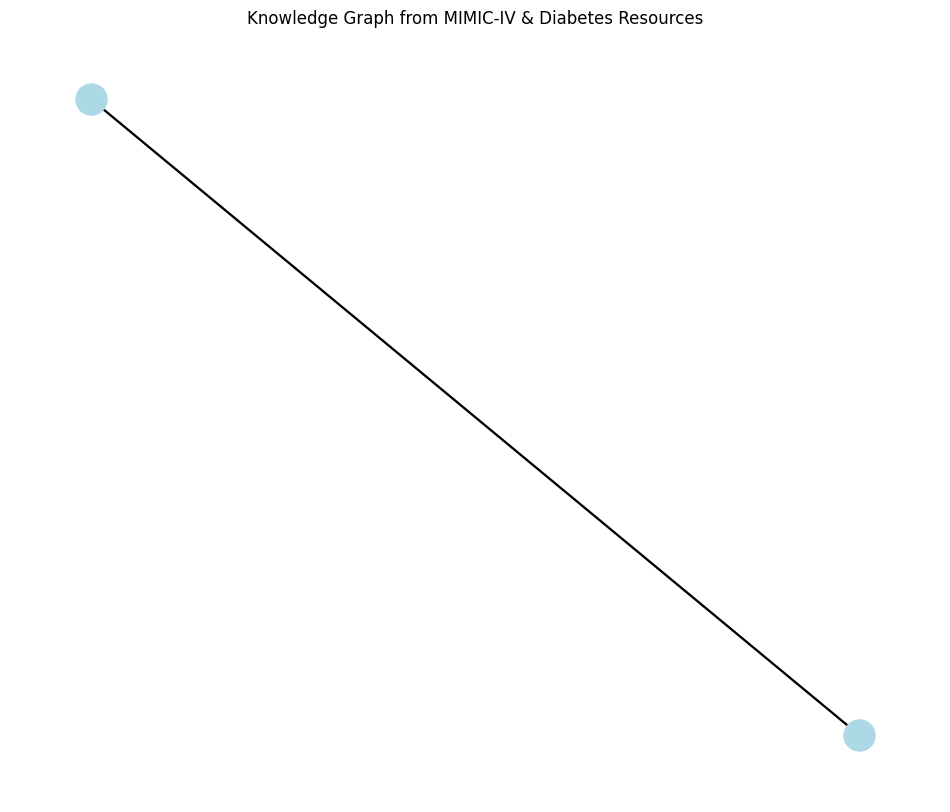

In [ ]:
# --- Step 5: Visualize the knowledge graph using NetworkX and Matplotlib
plt.figure(figsize=(12, 10))
pos = nx.spring_layout(KG, seed=RANDOM_SEED)  # positions for all nodes

# Draw nodes
nx.draw_networkx_nodes(KG, pos, node_size=500, node_color="lightblue")

# Draw edges with width proportional to similarity weight
edges = KG.edges(data=True)
edge_weights = [d["weight"] * 5 for (_, _, d) in edges]  # scale for visibility
nx.draw_networkx_edges(KG, pos, width=edge_weights)

# Create labels: show document source and a snippet of text
#labels = {i: f"{chunk_source[i]}: {all_chunks[i][:20]}..." for i in range(num_chunks)}
#nx.draw_networkx_labels(G, pos, labels, font_size=8)

plt.title("Knowledge Graph from MIMIC-IV & Diabetes Resources")
plt.axis("off")
plt.show()

# Note: For an interactive visualization, consider using Plotly or Bokeh in future iterations.


In [ ]:
# --- Step 6: RAG Example
# Process a New User Query and Generate a Personalized Prescription ---
def process_user_query(query):
    # Run intent detection on the query
    query_intent = gemini_intent_detection(query)
    # Run entity recognition on the query
    query_entities = gemini_entity_recognition(query)

    # Build a JSON payload for the query
    query_payload = {
        "query": query,
        "intent": query_intent,
        "entities": query_entities
    }

    # (Pseudo-code) Similarity search in Neptune:
    # Use the identified entities/intents to search for relevant nodes in the Neptune knowledge graph.
    # Here, we simulate by performing a TF-IDF similarity search on processed_data.
    query_vec = vectorizer.transform([query])
    similarities = cosine_similarity(query_vec, tfidf_matrix)[0]
    top_indices = similarities.argsort()[-3:][::-1]

    relevant_info = [processed_data[i] for i in top_indices]
    query_payload["retrieved"] = relevant_info

    # Final prompt for personalized prescription generation.
    final_prompt = f"You are a personalized prescription medicine agent. Based on the following patient query and retrieved medical data, generate a personalized prescription recommendation.\n\nQuery: {query}\n\nRetrieved Data:\n" + json.dumps(relevant_info, indent=2)

    # Call Gemini API for final answer (simulate here)
    final_answer = gemini_client.models.generate_content(model=GEMINI_MODEL_NAME, contents=final_prompt)
    # if final_answer.status_code == 200:
    #     generated_prescription = final_answer.json().get("generated_text", "No answer generated.")
    # else:
    #     generated_prescription = f"Error: {final_answer.status_code}"
    # query_payload["final_answer"] = generated_prescription
    #
    # return query_payload

    return final_answer.text

# Example: Process a new user query
new_query = "What personalized prescription is recommended for a diabetic patient with high HbA1c and kidney issues?"
result_payload = process_user_query(new_query)
print("\nFinal Query Processing Result:")
print(json.dumps(result_payload, indent=2))

Okay, let's break down the complexities of creating a personalized prescription for a diabetic patient with high HbA1c and kidney issues.  It's crucial to understand that **I am an AI and cannot provide medical advice. This information is for educational purposes only and should not be substituted for the guidance of a qualified healthcare professional.**  A doctor must assess the patient and tailor the prescription based on a comprehensive evaluation.

**Here's a detailed overview of the factors considered and potential medication classes involved in such a scenario, along with lifestyle modifications:**

**I. Key Considerations & Goals:**

*   **Glycemic Control (Lowering HbA1c):**  The primary goal is to reduce HbA1c to a target range that minimizes long-term complications. The target HbA1c will be individualized based on age, overall health, and the presence of other complications.  However, rapid lowering of HbA1c can sometimes worsen diabetic retinopathy, so a gradual approach is

NameError: name 'vectorizer' is not defined